Code from https://github.com/derekgreene/topic-model-tutorial

In [21]:
import joblib
import numpy as np
from sklearn import decomposition
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# settings for our plots later
plt.style.use("ggplot")
matplotlib.rcParams.update({"font.size": 14})

In [22]:
(A, terms, snippets) = joblib.load("../data/avisos-tfidf.pkl")
print("Loaded %d X %d document-term matrix" % (A.shape[0], A.shape[1]))

Loaded 593 X 2859 document-term matrix


In [23]:
k = 10

In [24]:
# create the model, specifiying the initialization strategy and the number of topics to produce
model = decomposition.NMF(init="nndsvd", n_components=k)
# apply the model and extract the two factor matrices
W = model.fit_transform(A)
H = model.components_

/home/ssparzival/.pyenv/versions/3.11.10/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [25]:
W.shape

(593, 10)

In [26]:
# round to 2 decimal places for display purposes
W[0, :].round(2)

array([0.  , 0.  , 0.09, 0.  , 0.  , 0.1 , 0.  , 0.  , 0.  , 0.  ])

In [27]:
H.shape

(10, 2859)

In [28]:
term_index = terms.index("cholito")
# round to 2 decimal places for display purposes
H[:, term_index].round(2)

array([0.21, 0.13, 0.23, 0.  , 0.09, 0.24, 0.11, 0.  , 0.07, 0.01])

In [29]:
def get_descriptor(terms, H, topic_index, top):
    # reverse sort the values to sort the indices
    top_indices = np.argsort(H[topic_index, :])[::-1]
    # now get the terms corresponding to the top-ranked indices
    top_terms = []
    for term_index in top_indices[0:top]:
        top_terms.append(terms[term_index])
    return top_terms

In [30]:
descriptors = []
for topic_index in range(k):
    descriptors.append(get_descriptor(terms, H, topic_index, 10))
    str_descriptor = ", ".join(descriptors[topic_index])
    print("Topic %02d: %s" % (topic_index + 1, str_descriptor))

Topic 01: casa, hacer, haber, patron, ser, responsable, poder, tener, fugar, calle
Topic 02: comercio, repetir, diciembre, septiembre, junio, febrero, julio, enero, noviembre, mayo
Topic 03: dar, razon, imprenta, paradero, persona, cholito, ano, gratificacion, patron, edad
Topic 04: ojo, cara, pequeno, boca, nariz, grande, regular, redonda, ser, chico
Topic 05: pantalon, azul, sombrero, camisa, color, vestido, pano, blanco, negro, muchacho
Topic 06: perder, recien, hablar, ocurrir, haber, encontrar, llegado, castellano, ocho, recibir
Topic 07: reglamento, policia, pena, sufrir, senalar, imponer, multa, persona, caso, retener
Topic 08: callao, saber, viruela, picado, ser, gratificar, tener, muchacho, cicatriz, nombrado
Topic 09: traje, nombrada, panuelon, muchacha, olar, casa, dar, pelo, blanco, vestido
Topic 10: ec, marzo, octubre, patrona, agosto, reimpreso, muchacho, repetir, entregar, casa


In [31]:
def plot_top_term_weights(terms, H, topic_index, top):
    # get the top terms and their weights
    top_indices = np.argsort(H[topic_index, :])[::-1]
    top_terms = []
    top_weights = []
    for term_index in top_indices[0:top]:
        top_terms.append(terms[term_index])
        top_weights.append(H[topic_index, term_index])
    # note we reverse the ordering for the plot
    top_terms.reverse()
    top_weights.reverse()
    # create the plot
    fig = plt.figure(figsize=(13, 8))
    # add the horizontal bar chart
    ypos = np.arange(top)
    ax = plt.barh(
        ypos, top_weights, align="center", color="green", tick_label=top_terms
    )
    plt.xlabel("Term Weight", fontsize=14)
    plt.tight_layout()
    plt.show()

Top terms for topic 01


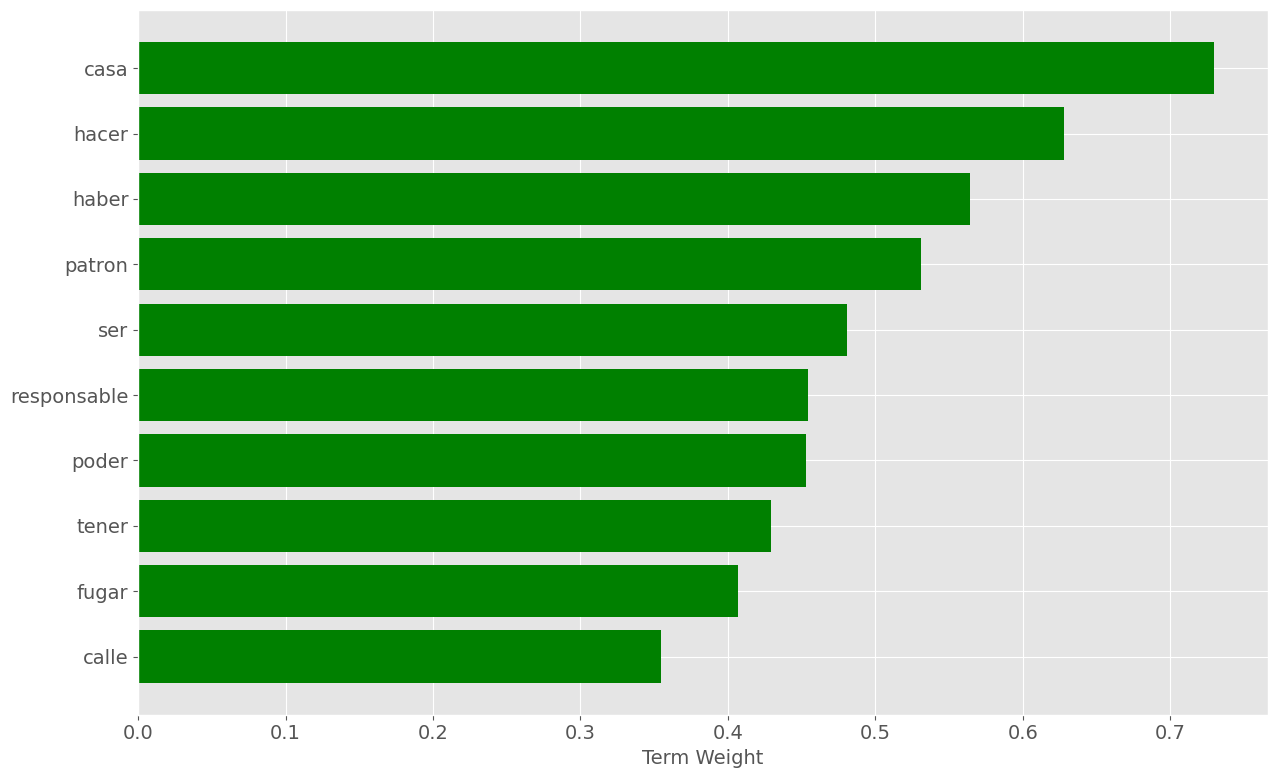

Top terms for topic 02


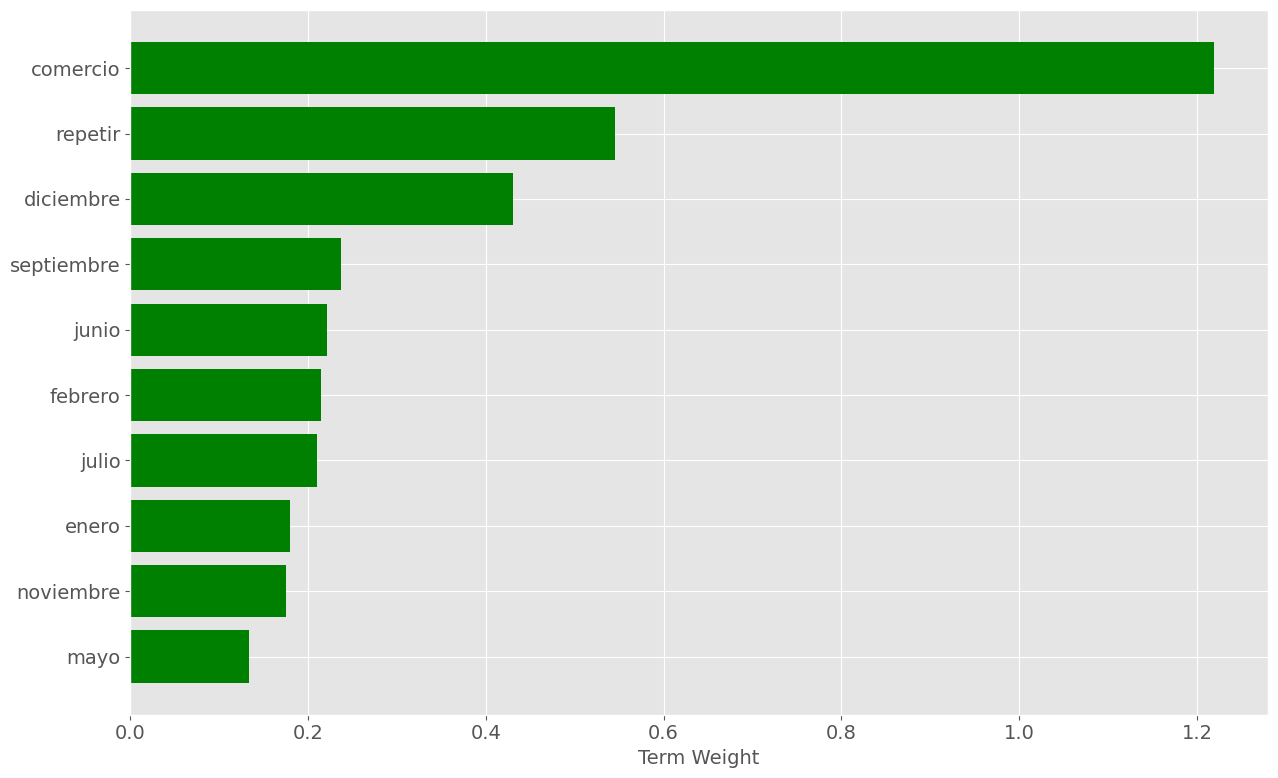

Top terms for topic 03


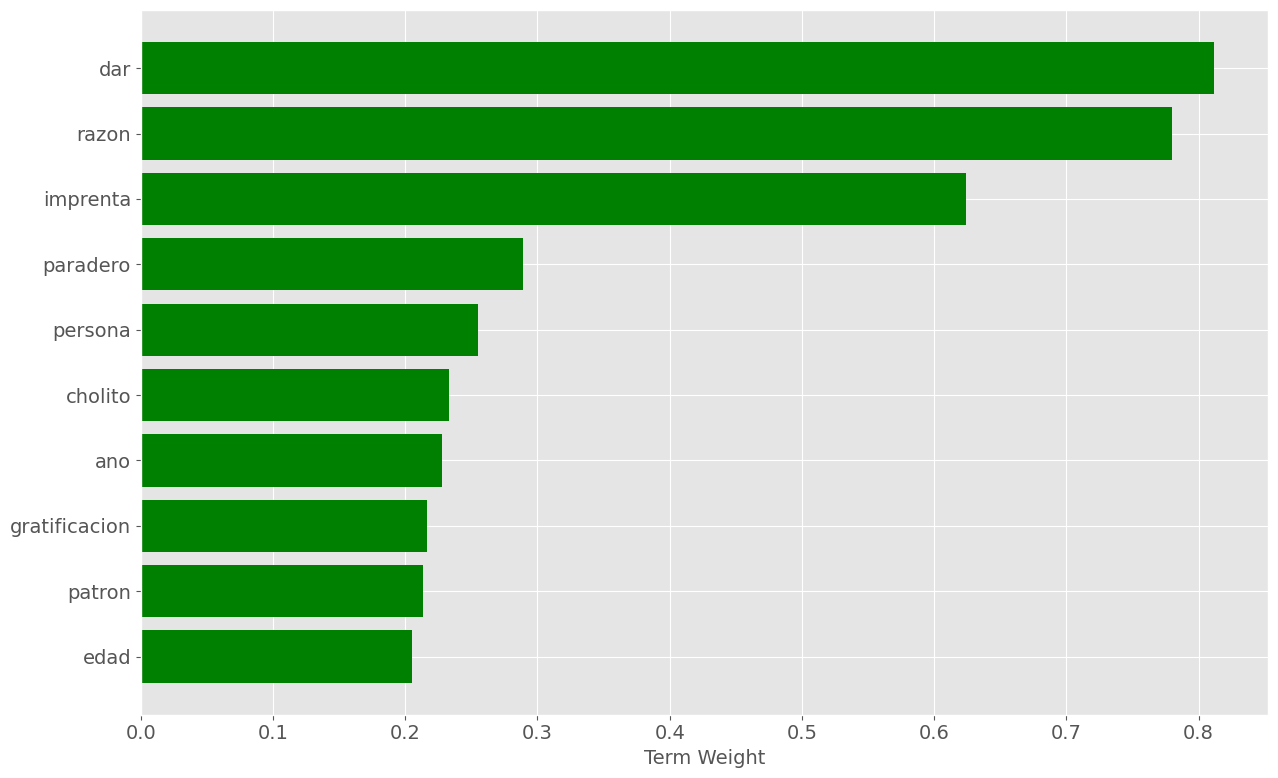

Top terms for topic 04


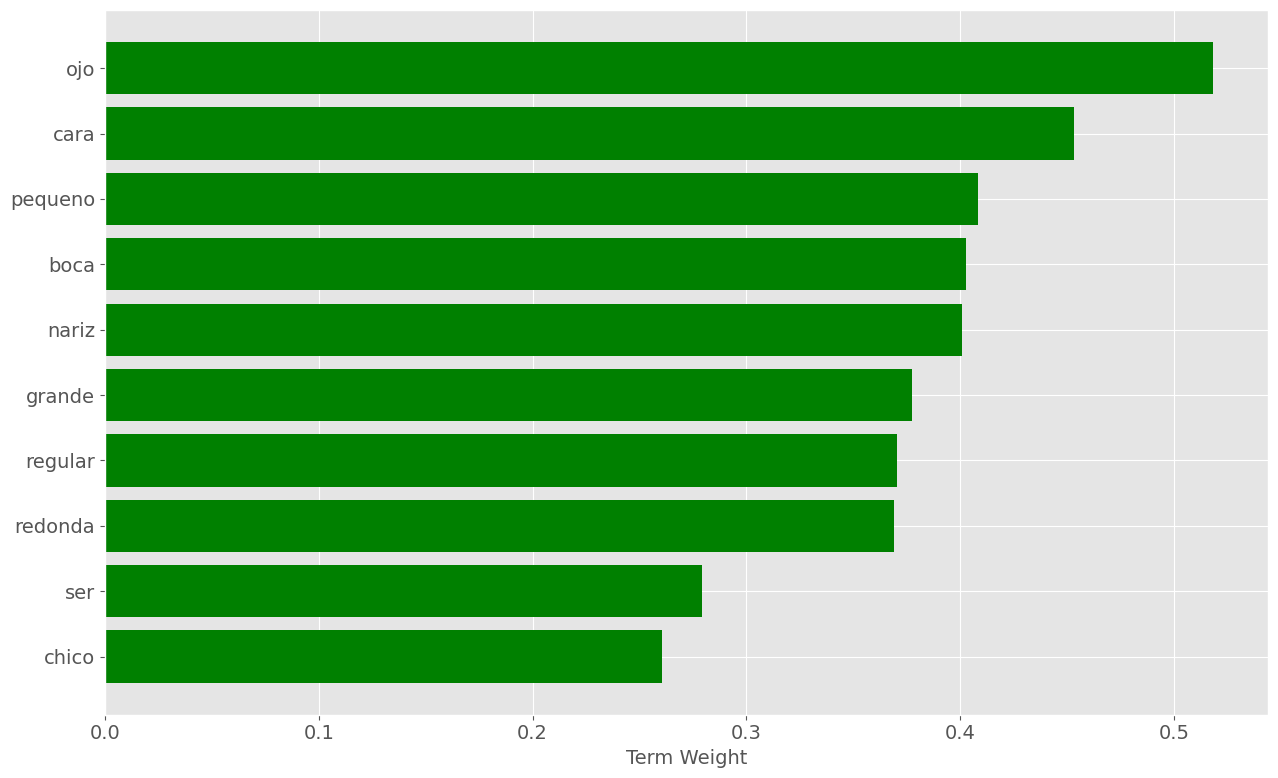

Top terms for topic 05


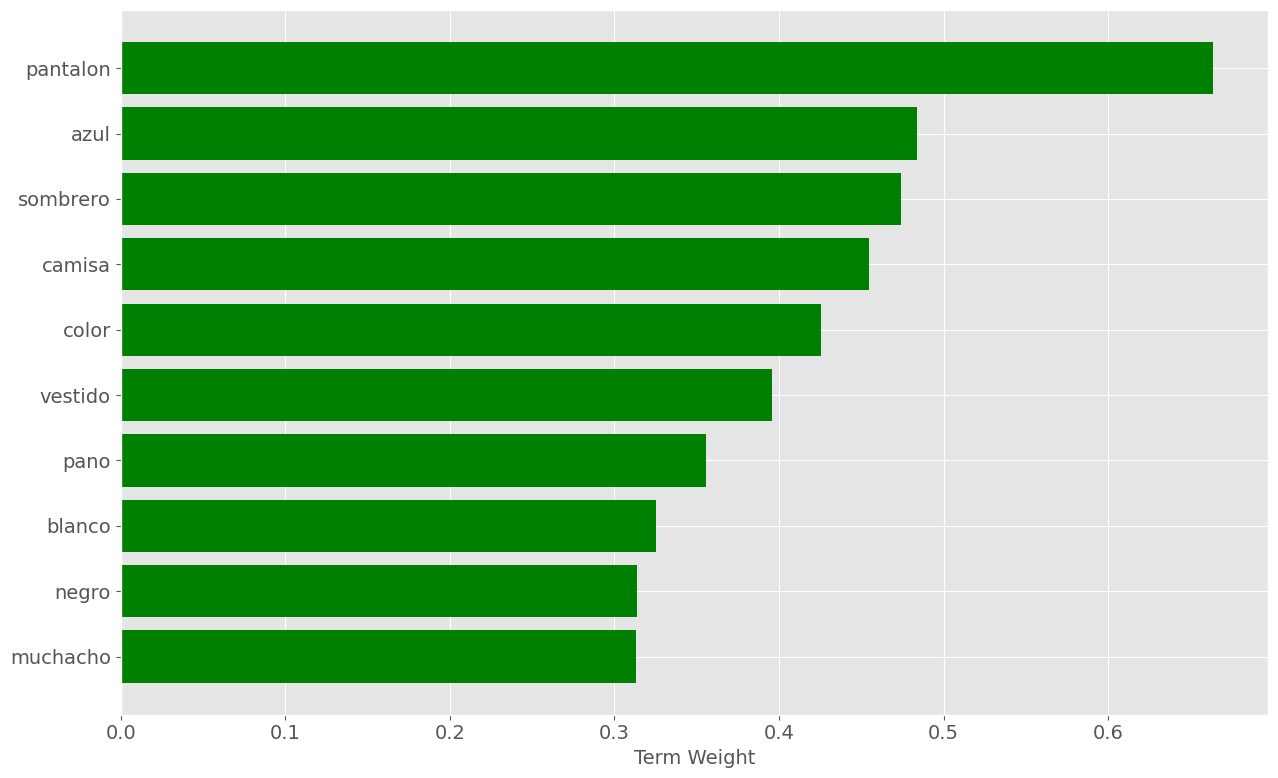

Top terms for topic 06


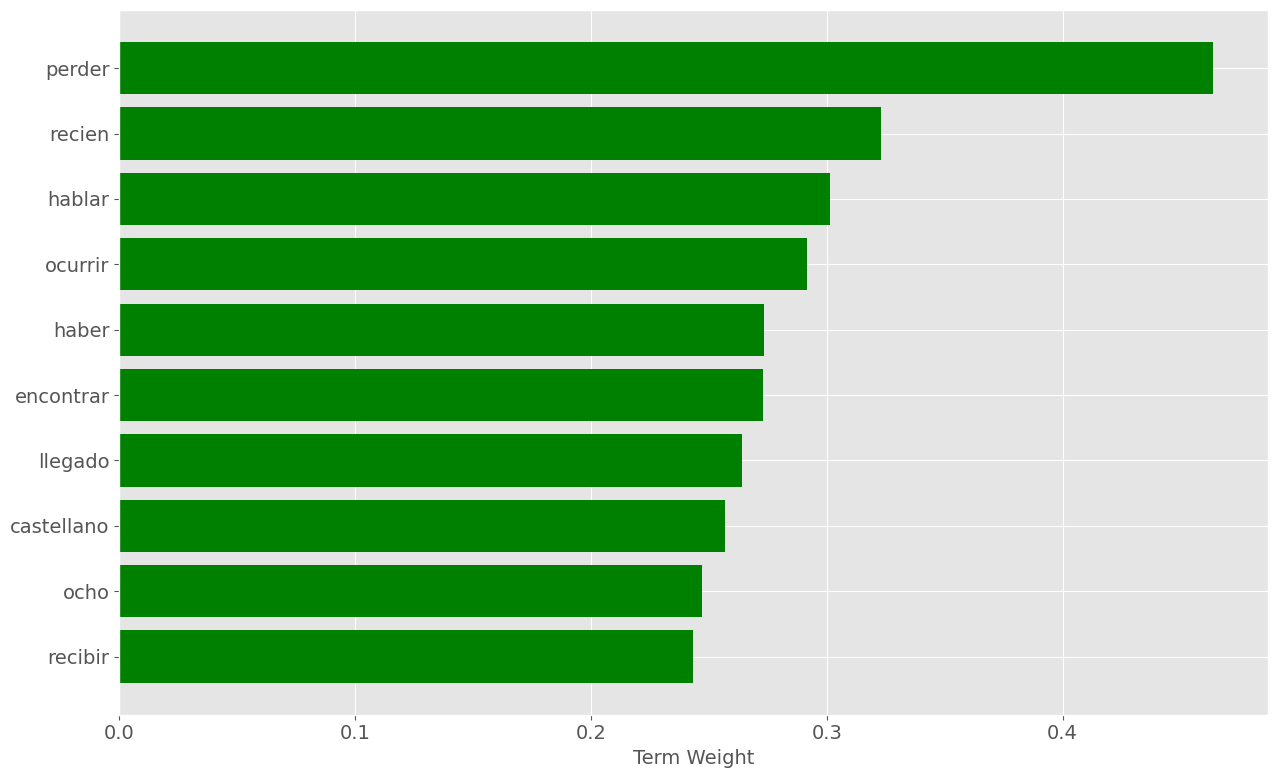

Top terms for topic 07


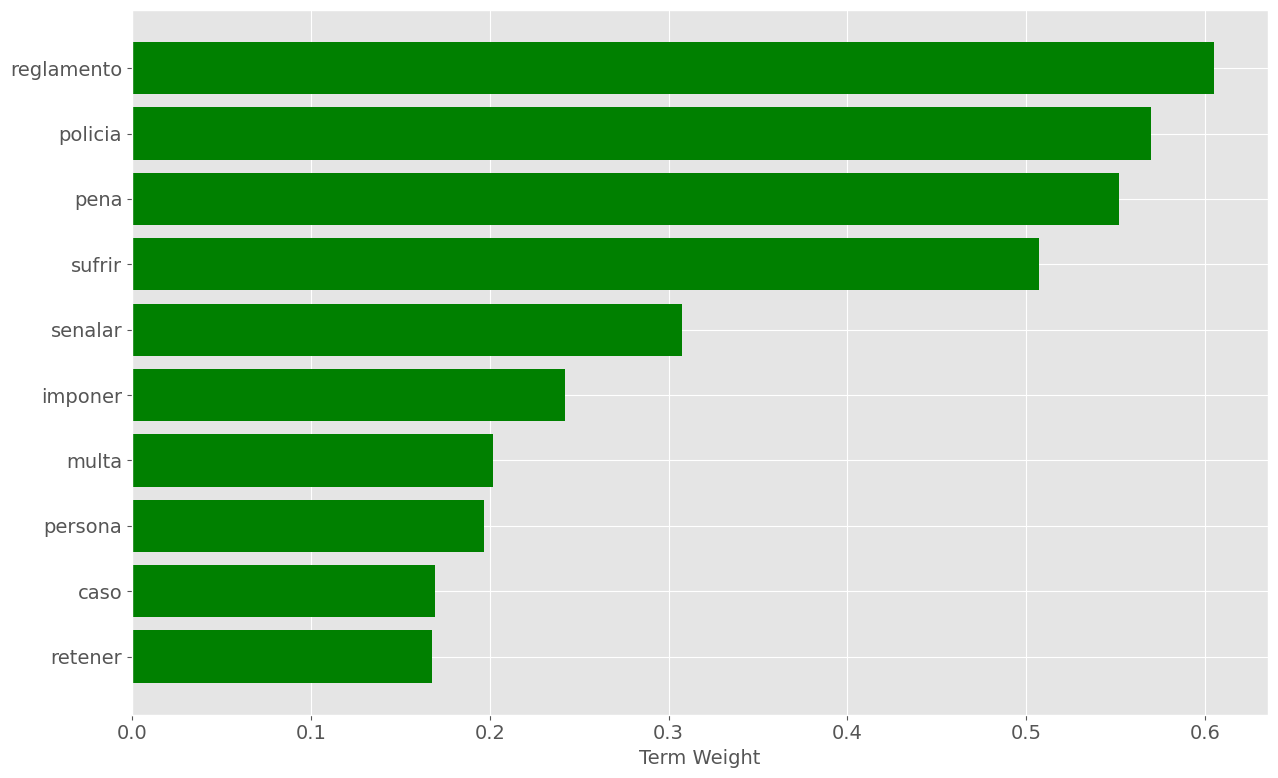

Top terms for topic 08


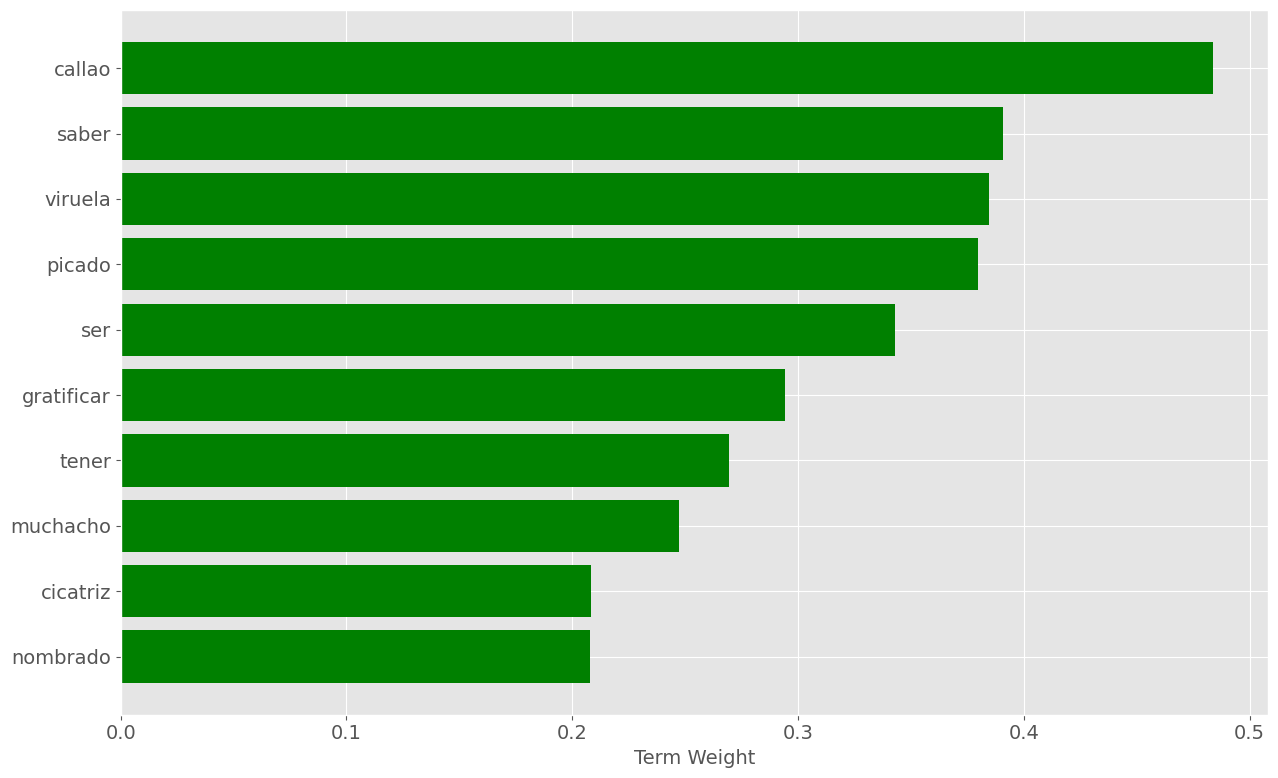

Top terms for topic 09


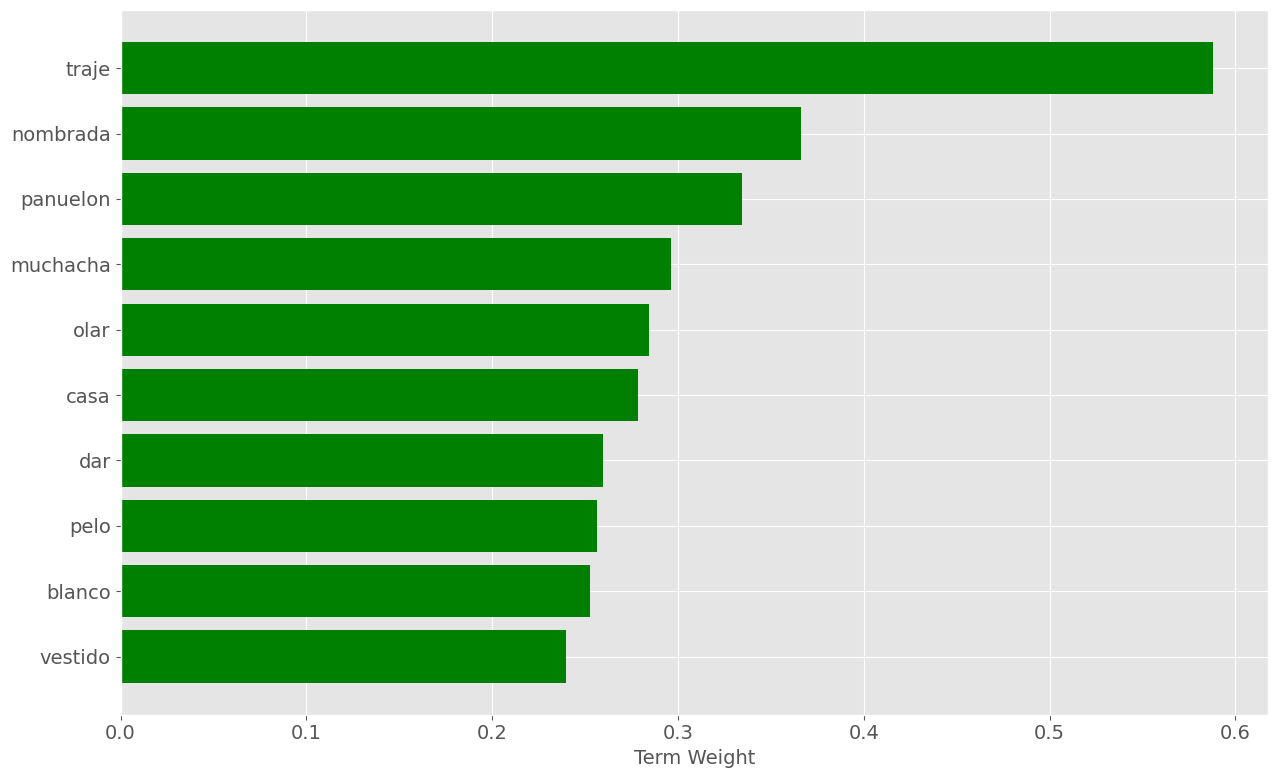

Top terms for topic 10


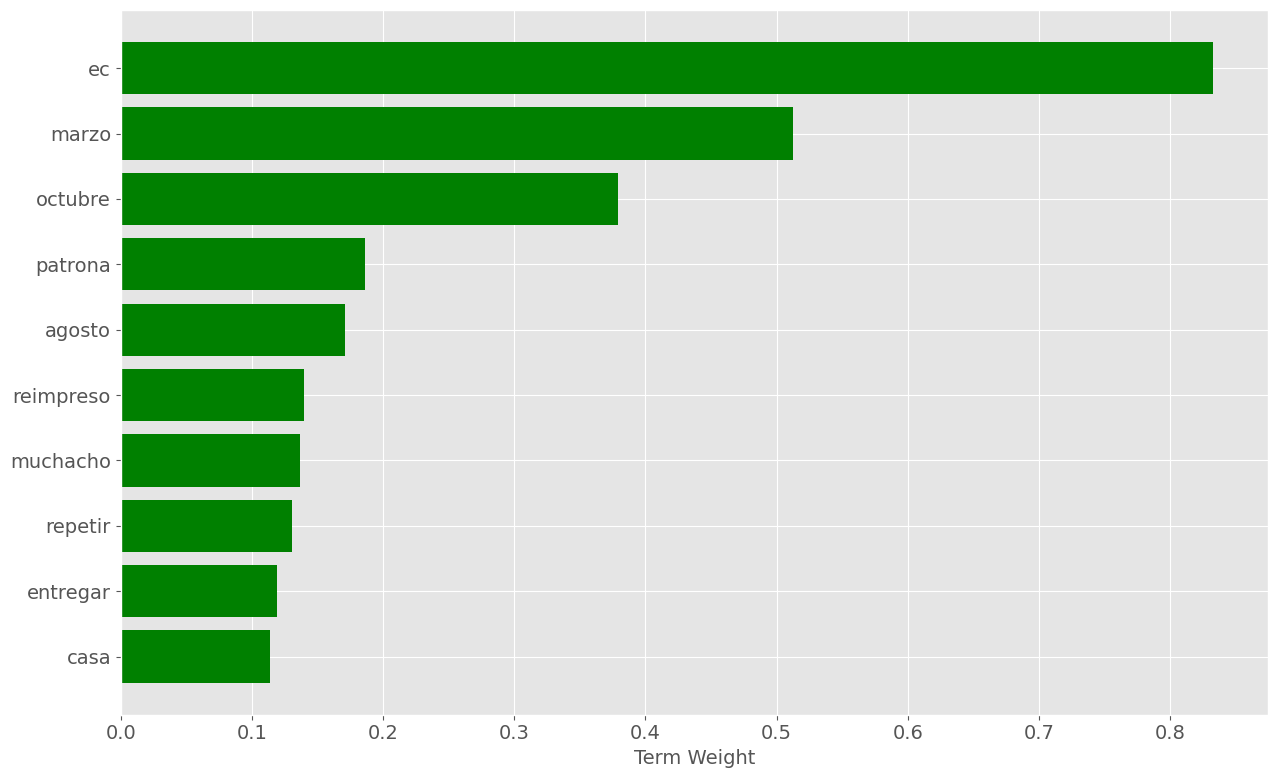

In [32]:
for topic_index in range(k):
    print("Top terms for topic %02d" % (topic_index + 1))
    plot_top_term_weights(terms, H, topic_index, 10)

In [33]:
def get_top_snippets(all_snippets, W, topic_index, top):
    # reverse sort the values to sort the indices
    top_indices = np.argsort(W[:, topic_index])[::-1]
    # now get the snippets corresponding to the top-ranked indices
    top_snippets = []
    for doc_index in top_indices[0:top]:
        top_snippets.append(all_snippets[doc_index])
    return top_snippets

In [34]:
topic_snippets = get_top_snippets(snippets, W, 0, 10)
for i, snippet in enumerate(topic_snippets):
    print("%02d. %s" % ((i + 1), snippet))

01. text_308
02. text_150
03. text_544
04. text_379
05. text_435
06. text_434
07. text_579
08. text_458
09. text_493
10. text_576


In [35]:
topic_snippets = get_top_snippets(snippets, W, 1, 10)
for i, snippet in enumerate(topic_snippets):
    print("%02d. %s" % ((i + 1), snippet))

01. text_175
02. text_257
03. text_110
04. text_477
05. text_247
06. text_415
07. text_462
08. text_238
09. text_138
10. text_224
